In [96]:
#!pip install lbforaging

## Foraging

**LB-Foraging** es un entorno *multi-agente* de recolección en cuadrícula con dos modos de juego.

### Espacio de acciones (por agente)

| Acción | Descripción |
|--------|-------------|
| NONE   | No hacer nada |
| NORTH  | Moverse al norte |
| SOUTH  | Moverse al sur |
| WEST   | Moverse al oeste |
| EAST   | Moverse al este |
| LOAD   | Recoger ítem adyacente |

### Observación (por agente)
Cada agente recibe un vector de 9 floats con posición y nivel de los agentes y del ítem visible.

### Recompensas
Un ítem se recoge cuando la suma de niveles de los agentes adyacentes que ejecutan **LOAD** ≥ nivel del ítem. La recompensa se distribuye entre los participantes. El episodio termina cuando se recoge el ítem o se alcanza el límite de pasos.

### Modos de juego

| Config | `force_coop` | Descripción |
|--------|:---:|---|
| `Foraging-8x8-2p-1f-v3` | ✗ | **Modo mixto**: el nivel del ítem es aleatorio; ~42 % de episodios requieren cooperación y ~58 % son competitivos (un agente puede recoger solo). |
| `Foraging-8x8-2p-1f-coop-v3` | ✓ | **Modo cooperativo**: el nivel del ítem siempre iguala la suma de niveles de los agentes, por lo que la cooperación es **obligatoria** en todos los episodios. |


###

> A diferencia de los juegos matriciales (MP, RPS), Foraging es un juego **secuencial con estado**. > El análisis se centra en la **recompensa acumulada por episodio** y la **tasa de éxito** como métricas de aprendizaje.

In [98]:
import lbforaging
from games.foraging import Foraging
import numpy as np
import time
import matplotlib.pyplot as plt
from agents.random_agent import RandomAgent
from agents.iql import IndependentQLearning
from agents.jal_am import JointActionLearningAM

## Inicialización del juego

In [100]:
game = Foraging(config=None, seed=1)

In [ ]:
game.reset()
for agent in game.agents:
    print(f"Agent {agent}")
    print(f"Observed state: {game.observe(agent)}")
    print(f"Observed actions: {game.observations[agent]}")

Agent agent_0
Observed state: [6. 2. 2. 4. 6. 2. 0. 1. 2.]
Observed actions: [6. 2. 2. 4. 6. 2. 0. 1. 2.]
Agent agent_1
Observed state: [6. 2. 2. 0. 1. 2. 4. 6. 2.]
Observed actions: [6. 2. 2. 0. 1. 2. 4. 6. 2.]


## Funciones utilitarias

In [ ]:
def play_episode(game, agents, verbose=False, render=False):

    # Initialize the game
    game.reset()

    # Print initial observations
    if verbose:
        print(f"Step: {game.current_step}")
        for agent in game.agents:
            print(f"Agent {agent}: {game.observe(agent)}")

    # Initialize rewards for each agent
    cum_rewards = dict(map(lambda agent: (agent, 0), game.agents))

    # render the game if required
    if render:
        game.render()
        time.sleep(0.5)

    while not game.done():

        # Get actions from each agent
        actions = dict(map(lambda agent: (agent, agents[agent].action()), game.agents))

        # Perform the actions in the game
        game.step(actions)

        # Update the cum_rewards for each agent
        for agent in game.agents:
            cum_rewards[agent] += game.reward(agent)

        # Print the rewards if verbose is enabled
        if verbose:
            print(f"Step: {game.current_step}")
            for agent in game.agents:
                print(f"Agent {agent} action: {actions[agent]} ({game.action_set[actions[agent]]})")
                print(f"Agent {agent} reward: {game.reward(agent)}")
                print(f"Agent {agent} next state: {game.observe(agent)}")
                print(f"Agent {agent} joint action: {game.observations[agent]}")
        
        if render:
            game.render()
            time.sleep(0.5)
        
    return cum_rewards

In [102]:
agent_dict = dict(map(lambda agent: (agent, RandomAgent(game=game, agent=agent)), game.agents))

In [ ]:
def run(game, agent_dict, n_episodes=100, verbose=False, render=False):
    total_rewards = dict(map(lambda agent: (agent, 0), game.agents))
    for episode in range(n_episodes):
        if verbose:
            print(f"-- Episode: {episode}")
        cum_rewards = play_episode(game, agent_dict, verbose=verbose, render=render)
        for agent in game.agents:
            total_rewards[agent] += cum_rewards[agent]
        if verbose:
            for agent in game.agents:
                print(f"Total rewards {agent}: {total_rewards[agent]}")
            print("--")
    return total_rewards

In [103]:
def track_rewards(game, agents, n_episodes=500):
    """Ejecuta n_episodes y retorna las recompensas por episodio para cada agente."""
    history = {a: [] for a in game.agents}
    for _ in range(n_episodes):
        cum_rewards = play_episode(game, agents)
        for a in game.agents:
            history[a].append(cum_rewards[a])
        for ag in agents.values():
            if hasattr(ag, 'reset'):
                ag.reset()
    return history


def plot_rewards(history, title, window=30):
    """Grafica la media móvil de recompensas por episodio."""
    fig, ax = plt.subplots(figsize=(8, 4))
    for agent, rewards in history.items():
        arr = np.array(rewards)
        if len(arr) >= window:
            rolling = np.convolve(arr, np.ones(window) / window, mode='valid')
            ax.plot(range(window, len(arr) + 1), rolling, label=agent)
        else:
            ax.plot(arr, label=agent)
    ax.set_xlabel('Episodio')
    ax.set_ylabel(f'Recompensa acumulada (media móvil, ventana={window})')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [104]:
def track_convergence(game, agents, checkpoints):
    """Registra la recompensa promedio por episodio en cada checkpoint."""
    history = {a: [] for a in game.agents}
    episode = 0
    for cp in checkpoints:
        chunk = {a: [] for a in game.agents}
        for _ in range(cp - episode):
            cum_rewards = play_episode(game, agents)
            for a in game.agents:
                chunk[a].append(cum_rewards[a])
            for ag in agents.values():
                if hasattr(ag, 'reset'):
                    ag.reset()
        episode = cp
        for a in game.agents:
            history[a].append(np.mean(chunk[a]) if chunk[a] else 0.0)
    return history


def plot_convergence(history, checkpoints, title):
    """Grafica la recompensa promedio por episodio en cada checkpoint (escala log)."""
    fig, ax = plt.subplots(figsize=(8, 4))
    for agent, values in history.items():
        ax.plot(checkpoints, values, marker='o', label=agent)
    ax.set_xscale('log')
    ax.set_xlabel('Episodios (escala log)')
    ax.set_ylabel('Recompensa promedio por episodio')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [105]:
def track_success_rate(game, agents, checkpoints):
    """Registra la fracción de episodios con recompensa positiva en cada checkpoint."""
    history = {a: [] for a in game.agents}
    episode = 0
    for cp in checkpoints:
        chunk_size = cp - episode
        successes = {a: 0 for a in game.agents}
        for _ in range(chunk_size):
            cum_rewards = play_episode(game, agents)
            for a in game.agents:
                if cum_rewards[a] > 0:
                    successes[a] += 1
            for ag in agents.values():
                if hasattr(ag, 'reset'):
                    ag.reset()
        episode = cp
        for a in game.agents:
            history[a].append(successes[a] / chunk_size if chunk_size > 0 else 0.0)
    return history


def plot_success_rate(history, checkpoints, title, nash_eq=1.0):
    """Grafica P(comida recogida) por checkpoint (escala log) con línea de Nash."""
    fig, ax = plt.subplots(figsize=(8, 4))
    for agent, values in history.items():
        ax.plot(checkpoints, values, marker='o', label=agent)
    ax.axhline(nash_eq, color='gray', linestyle='--',
               label=f'Nash equilibrium ({nash_eq})')
    ax.set_xscale('log')
    ax.set_ylim(-0.05, 1.15)
    ax.set_xlabel('Episodios (escala log)')
    ax.set_ylabel('P(comida recogida)')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
def compute_nash_eq(game, n_samples=2000):
    """
    Estima el Nash esperado de P(comida recogida) por agente según la config del juego.

    - force_coop=True  → Nash = 1.0 (cooperación siempre obligatoria)
    - force_coop=False → mezcla de episodios cooperativos (Nash=1.0) y
                         competitivos (Nash≈0.5 por agente en carrera simétrica)
    """
    env = game.env.unwrapped
    if env.force_coop:
        return 1.0

    rng = np.random.default_rng(42)
    coop_count = 0
    for _ in range(n_samples):
        game.env.reset(seed=int(rng.integers(1_000_000)))
        player_levels = [p.level for p in env.players]
        food_positions = list(zip(*env.field.nonzero()))
        if not food_positions:
            continue
        r, c = food_positions[0]
        food_level = env.field[r, c]
        if food_level > max(player_levels):
            coop_count += 1          # ningún agente puede solo

    p_coop = coop_count / n_samples
    # episodios cooperativos: Nash=1.0; competitivos: Nash≈0.5 (carrera simétrica)
    return round(p_coop * 1.0 + (1 - p_coop) * 0.5, 4)

## Exploración del entorno

Se ejecuta **1 episodio** en modo verbose para observar la dinámica paso a paso.

In [107]:
run(game=game, agent_dict=agent_dict, n_episodes=1, verbose=True, render=False)

-- Episode: 0
Step: 0
Agent agent_0: [2. 6. 1. 7. 0. 1. 6. 7. 1.]
Agent agent_1: [2. 6. 1. 6. 7. 1. 7. 0. 1.]
Step: 1
Agent agent_0 action: 4 (EAST)
Agent agent_0 reward: 0
Agent agent_0 next state: [2. 6. 1. 7. 1. 1. 6. 7. 1.]
Agent agent_0 joint action: [2. 6. 1. 7. 1. 1. 6. 7. 1.]
Agent agent_1 action: 4 (EAST)
Agent agent_1 reward: 0
Agent agent_1 next state: [2. 6. 1. 6. 7. 1. 7. 1. 1.]
Agent agent_1 joint action: [2. 6. 1. 6. 7. 1. 7. 1. 1.]
Step: 2
Agent agent_0 action: 4 (EAST)
Agent agent_0 reward: 0
Agent agent_0 next state: [2. 6. 1. 7. 2. 1. 6. 6. 1.]
Agent agent_0 joint action: [2. 6. 1. 7. 2. 1. 6. 6. 1.]
Agent agent_1 action: 3 (WEST)
Agent agent_1 reward: 0
Agent agent_1 next state: [2. 6. 1. 6. 6. 1. 7. 2. 1.]
Agent agent_1 joint action: [2. 6. 1. 6. 6. 1. 7. 2. 1.]
Step: 3
Agent agent_0 action: 0 (NONE)
Agent agent_0 reward: 0
Agent agent_0 next state: [2. 6. 1. 7. 2. 1. 6. 7. 1.]
Agent agent_0 joint action: [2. 6. 1. 7. 2. 1. 6. 7. 1.]
Agent agent_1 action: 4 (EAST)


/Users/nataliacampigliastemphelet/master/simultaneous-games/.venv/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'list'>
  logger.warn(


{'agent_0': 0, 'agent_1': 0}

In [108]:
jalam_agent_dict = dict(map(lambda agent: (agent, JointActionLearningAM(game=game, agent=agent)), game.agents))

In [109]:
run(game=game, agent_dict=jalam_agent_dict, n_episodes=1, verbose=True, render=False)

-- Episode: 0
Step: 0
Agent agent_0: [6. 2. 2. 4. 6. 2. 0. 1. 2.]
Agent agent_1: [6. 2. 2. 0. 1. 2. 4. 6. 2.]
Step: 1
Agent agent_0 action: 5 (LOAD)
Agent agent_0 reward: 0
Agent agent_0 next state: [6. 2. 2. 4. 6. 2. 0. 1. 2.]
Agent agent_0 joint action: [6. 2. 2. 4. 6. 2. 0. 1. 2.]
Agent agent_1 action: 0 (NONE)
Agent agent_1 reward: 0
Agent agent_1 next state: [6. 2. 2. 0. 1. 2. 4. 6. 2.]
Agent agent_1 joint action: [6. 2. 2. 0. 1. 2. 4. 6. 2.]
Step: 2
Agent agent_0 action: 1 (NORTH)
Agent agent_0 reward: 0
Agent agent_0 next state: [6. 2. 2. 3. 6. 2. 0. 1. 2.]
Agent agent_0 joint action: [6. 2. 2. 3. 6. 2. 0. 1. 2.]
Agent agent_1 action: 5 (LOAD)
Agent agent_1 reward: 0
Agent agent_1 next state: [6. 2. 2. 0. 1. 2. 3. 6. 2.]
Agent agent_1 joint action: [6. 2. 2. 0. 1. 2. 3. 6. 2.]
Step: 3
Agent agent_0 action: 3 (WEST)
Agent agent_0 reward: 0
Agent agent_0 next state: [6. 2. 2. 3. 5. 2. 0. 1. 2.]
Agent agent_0 joint action: [6. 2. 2. 3. 5. 2. 0. 1. 2.]
Agent agent_1 action: 5 (LOAD)

{'agent_0': 0, 'agent_1': 0}

## Experimentos: recompensas acumuladas

Se comparan las distintas combinaciones de agentes ejecutando **200 episodios**. \
Los agentes de aprendizaje (IQL, JAL-AM) acumulan experiencia a lo largo de los episodios.

### Random vs Random

In [112]:
agents = {a: RandomAgent(game=game, agent=a) for a in game.agents}
run(game=game, agent_dict=agents, n_episodes=200)

{'agent_0': 30.166666666666668, 'agent_1': 15.833333333333334}

### IQL vs Random

In [ ]:
agents = {'agent_0': IndependentQLearning(game=game, agent='agent_0'),
          'agent_1': RandomAgent(game=game, agent='agent_1')}
run(game=game, agent_dict=agents, n_episodes=200)

{'agent_0': 28.0, 'agent_1': 15.0}

### IQL vs IQL

In [ ]:
agents = {a: IndependentQLearning(game=game, agent=a) for a in game.agents}
run(game=game, agent_dict=agents, n_episodes=200)

{'agent_0': 27.0, 'agent_1': 16.0}

### JAL-AM vs JAL-AM

In [ ]:
agents = {a: JointActionLearningAM(game=game, agent=a) for a in game.agents}
run(game=game, agent_dict=agents, n_episodes=200)

{'agent_0': 37.0, 'agent_1': 22.0}

### IQL vs JAL-AM

In [17]:
agents = {'agent_0': IndependentQLearning(game=game, agent='agent_0'),
          'agent_1': JointActionLearningAM(game=game, agent='agent_1')}
run(game=game, agent_dict=agents, n_episodes=200)

{'agent_0': 41.0, 'agent_1': 22.0}

## Análisis de Convergencia

Se registra la recompensa acumulada en cada episodio y se grafica la media móvil \
para visualizar el aprendizaje a lo largo del tiempo (500 episodios, ventana=30).

In [18]:
N_EPISODES = 2_000

### Random vs Random

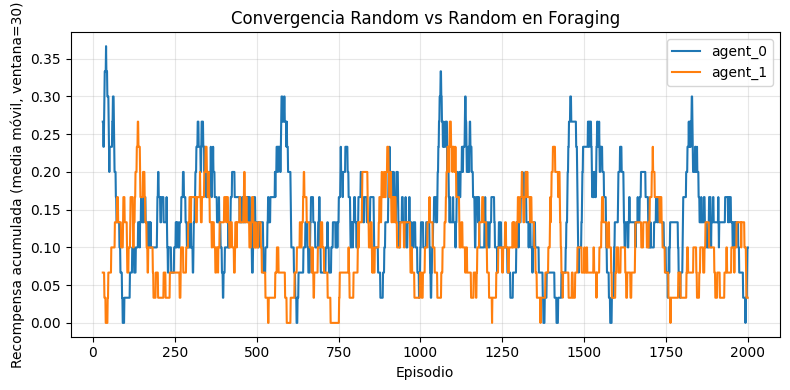

In [19]:
agents = {a: RandomAgent(game=game, agent=a) for a in game.agents}
history = track_rewards(game, agents, n_episodes=N_EPISODES)
plot_rewards(history, 'Convergencia Random vs Random en Foraging')

### IQL vs Random

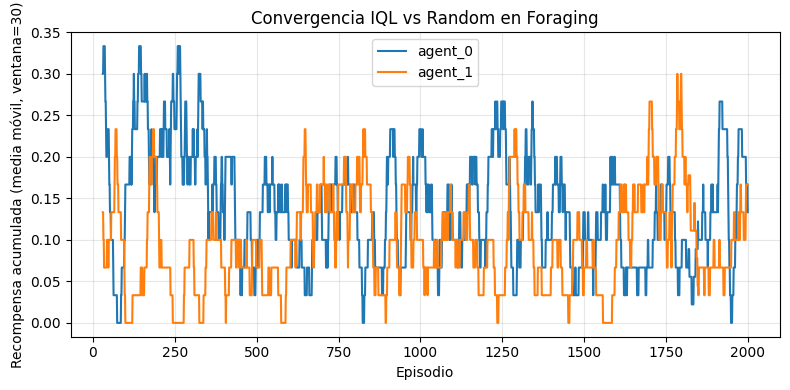

In [20]:
agents = {'agent_0': IndependentQLearning(game=game, agent='agent_0'),
          'agent_1': RandomAgent(game=game, agent='agent_1')}
history = track_rewards(game, agents, n_episodes=N_EPISODES)
plot_rewards(history, 'Convergencia IQL vs Random en Foraging')

### IQL vs IQL

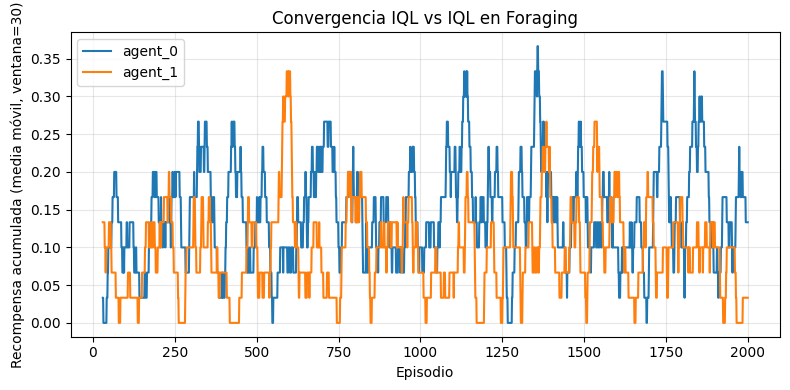

In [21]:
agents = {a: IndependentQLearning(game=game, agent=a) for a in game.agents}
history = track_rewards(game, agents, n_episodes=N_EPISODES)
plot_rewards(history, 'Convergencia IQL vs IQL en Foraging')

### JAL-AM vs JAL-AM

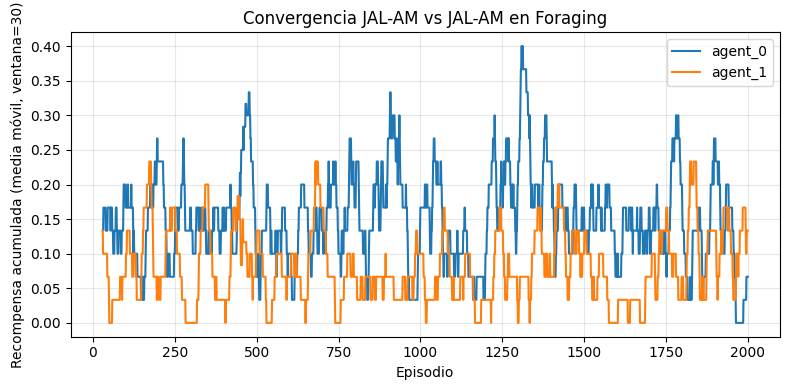

In [22]:
agents = {a: JointActionLearningAM(game=game, agent=a) for a in game.agents}
history = track_rewards(game, agents, n_episodes=N_EPISODES)
plot_rewards(history, 'Convergencia JAL-AM vs JAL-AM en Foraging')

### IQL vs JAL-AM

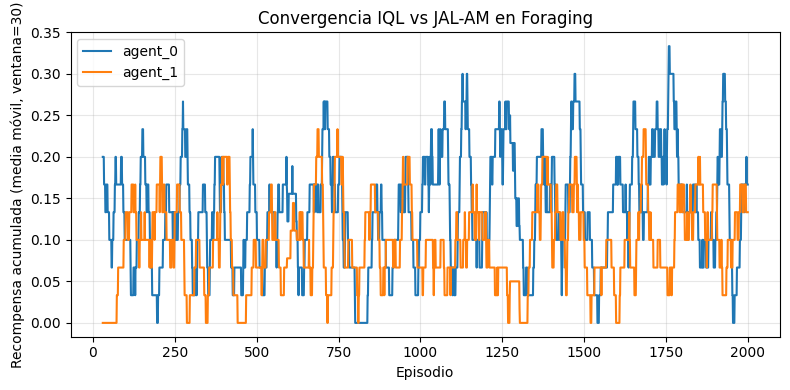

In [ ]:
agents = {'agent_0': IndependentQLearning(game=game, agent='agent_0'),
          'agent_1': JointActionLearningAM(game=game, agent='agent_1')}
history = track_rewards(game, agents, n_episodes=N_EPISODES)
plot_rewards(history, 'Convergencia IQL vs JAL-AM en Foraging')

## Análisis de Convergencia hacia el Equilibrio de Nash

Se registra la **recompensa promedio por episodio** en cada checkpoint (escala logarítmica) \
para visualizar el aprendizaje a lo largo del tiempo.

> En Foraging no hay un equilibrio de Nash de estrategia pura trivial como en MP. \
> La mejora en recompensa promedio es el proxy de convergencia hacia estrategias más eficientes.

In [ ]:
checkpoints = [10, 50, 100, 500, 1000, 5000, 10000]

### Random vs Random

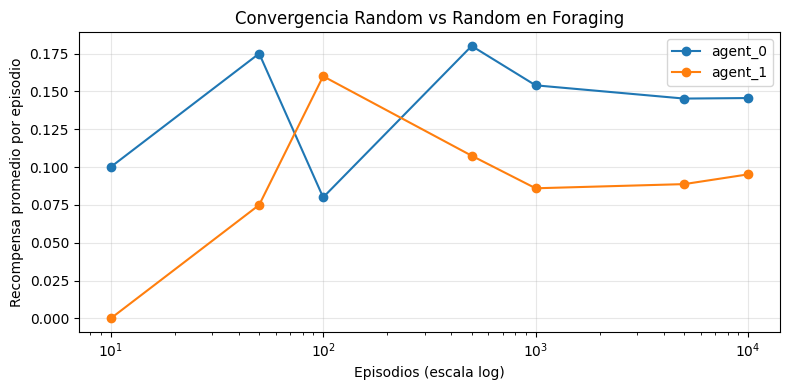

In [ ]:
agents = {a: RandomAgent(game=game, agent=a) for a in game.agents}
history = track_convergence(game, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia Random vs Random en Foraging')

### IQL vs Random

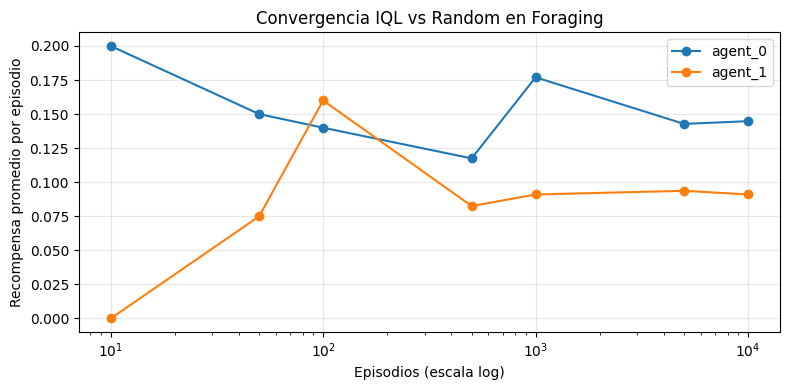

In [ ]:
agents = {'agent_0': IndependentQLearning(game=game, agent='agent_0'),
          'agent_1': RandomAgent(game=game, agent='agent_1')}
history = track_convergence(game, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia IQL vs Random en Foraging')

### IQL vs IQL

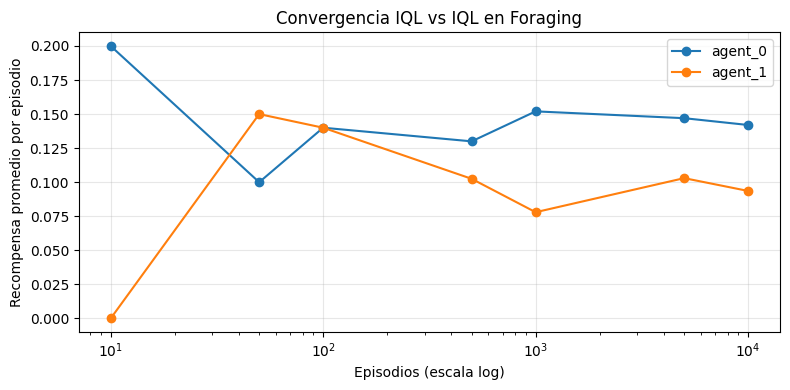

In [ ]:
agents = {a: IndependentQLearning(game=game, agent=a) for a in game.agents}
history = track_convergence(game, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia IQL vs IQL en Foraging')

### JAL-AM vs JAL-AM

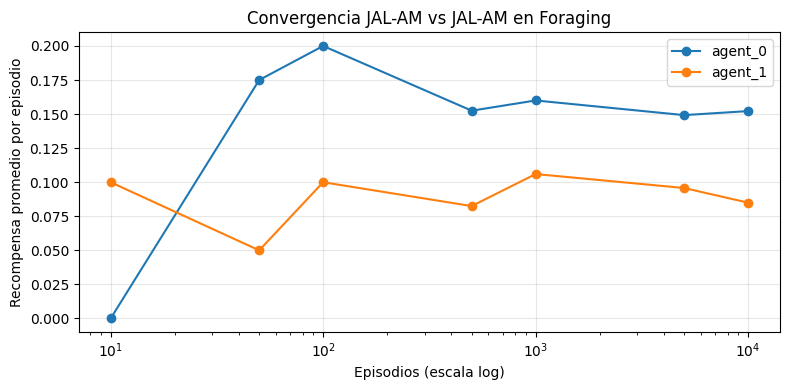

In [ ]:
agents = {a: JointActionLearningAM(game=game, agent=a) for a in game.agents}
history = track_convergence(game, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia JAL-AM vs JAL-AM en Foraging')

### IQL vs JAL-AM

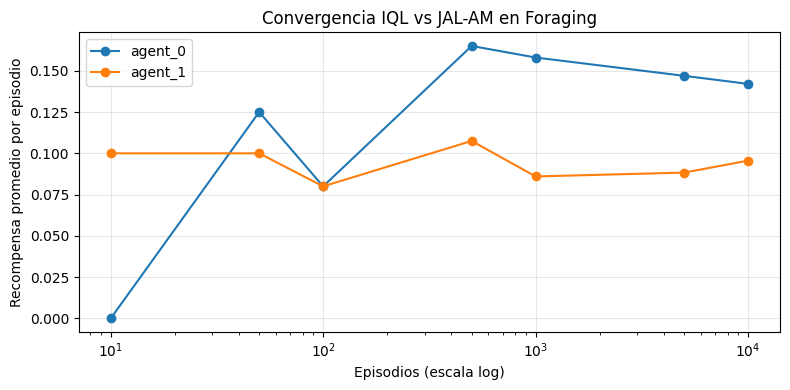

In [29]:
agents = {'agent_0': IndependentQLearning(game=game, agent='agent_0'),
          'agent_1': JointActionLearningAM(game=game, agent='agent_1')}
history = track_convergence(game, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia IQL vs JAL-AM en Foraging')

## Tasa de Éxito como Proxy del Equilibrio de Nash — Modo Mixto (`Foraging-8x8-2p-1f-v3`)

En esta configuración (`force_coop=False`) el nivel del ítem es aleatorio cada episodio:
- **~42 % de episodios**: cooperación obligatoria → Nash local = 1.0 por agente.
- **~58 % de episodios**: un agente puede recoger solo → carrera simétrica, Nash local ≈ 0.5 por agente.

El **Nash esperado** se estima como `p_coop × 1.0 + (1 − p_coop) × 0.5 ≈ 0.71` y se calcula dinámicamente. Se usa **P(comida recogida por agente)** como proxy escalar (análogo a P(H) en MP), con escala log en el eje x.

Nash esperado estimado dinámicamente sobre 2 000 resets del juego real (`force_coop=False`, niveles ∈ {1,2}, nivel de ítem aleatorio):

In [ ]:
nash_eq = compute_nash_eq(game)
print(f'Nash equilibrium estimado: {nash_eq}')

Nash equilibrium estimado: 0.7077


### Random vs Random

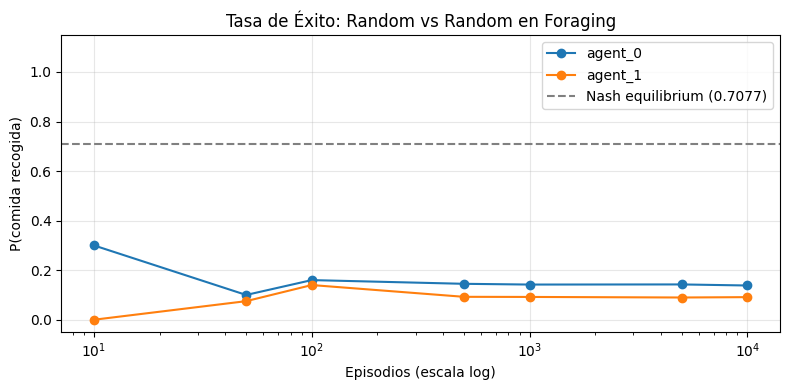

In [32]:
agents = {a: RandomAgent(game=game, agent=a) for a in game.agents}
history = track_success_rate(game, agents, checkpoints)
plot_success_rate(history, checkpoints, 'Tasa de Éxito: Random vs Random en Foraging', nash_eq=nash_eq)

### IQL vs Random

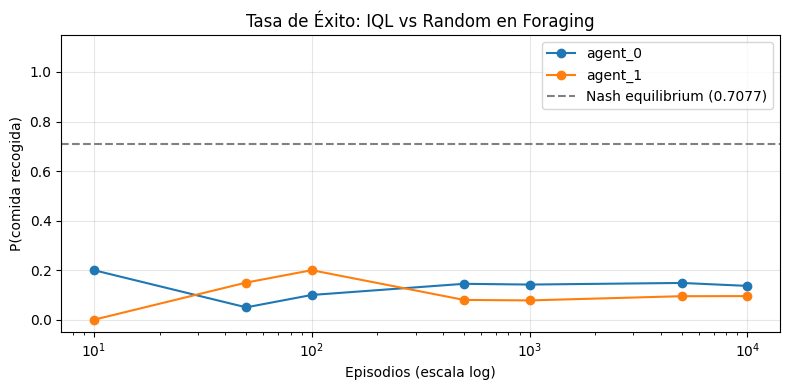

In [33]:
agents = {'agent_0': IndependentQLearning(game=game, agent='agent_0'),
          'agent_1': RandomAgent(game=game, agent='agent_1')}
history = track_success_rate(game, agents, checkpoints)
plot_success_rate(history, checkpoints, 'Tasa de Éxito: IQL vs Random en Foraging', nash_eq=nash_eq)

### IQL vs IQL

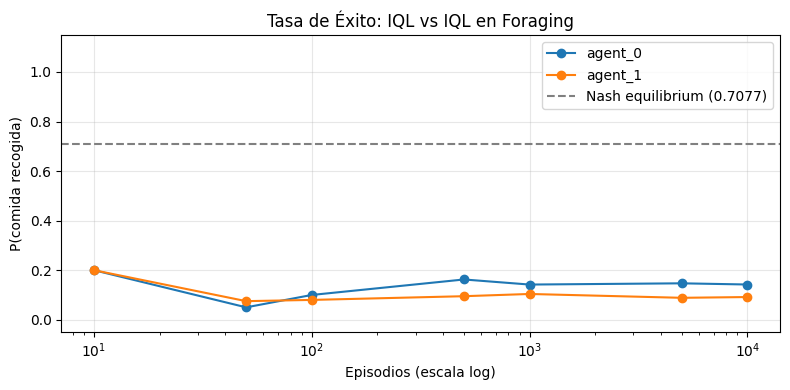

In [34]:
agents = {a: IndependentQLearning(game=game, agent=a) for a in game.agents}
history = track_success_rate(game, agents, checkpoints)
plot_success_rate(history, checkpoints, 'Tasa de Éxito: IQL vs IQL en Foraging', nash_eq=nash_eq)

### JAL-AM vs JAL-AM

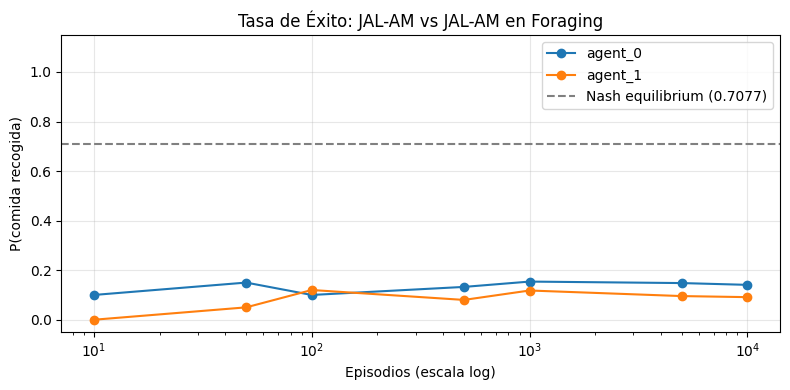

In [35]:
agents = {a: JointActionLearningAM(game=game, agent=a) for a in game.agents}
history = track_success_rate(game, agents, checkpoints)
plot_success_rate(history, checkpoints, 'Tasa de Éxito: JAL-AM vs JAL-AM en Foraging', nash_eq=nash_eq)

### IQL vs JAL-AM

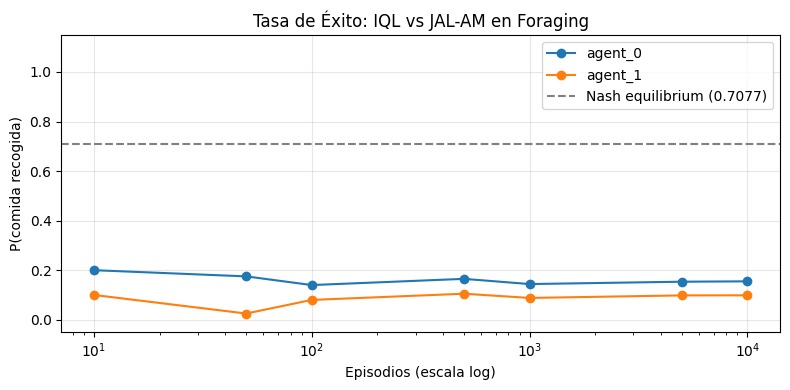

In [36]:
agents = {'agent_0': IndependentQLearning(game=game, agent='agent_0'),
          'agent_1': JointActionLearningAM(game=game, agent='agent_1')}
history = track_success_rate(game, agents, checkpoints)
plot_success_rate(history, checkpoints, 'Tasa de Éxito: IQL vs JAL-AM en Foraging', nash_eq=nash_eq)

## Tasa de Éxito como Proxy del Equilibrio de Nash — Modo Cooperativo (`Foraging-8x8-2p-1f-coop-v3`)

En esta configuración (`force_coop=True`) el nivel del ítem siempre iguala la suma de niveles de los agentes, por lo que **ningún agente puede recoger el ítem solo**: la cooperación es **obligatoria** en todos los episodios.

**¿Por qué la tasa de éxito es cercana a cero?**

Para recoger el ítem se requiere que **ambos** agentes estén adyacentes al ítem y elijan **LOAD** en el **mismo step**:

| Evento | Probabilidad aproximada |
|--------|------------------------|
| Un agente adyacente al ítem | 4/64 ≈ 6.25 % |
| Ambos adyacentes simultáneamente | (4/64)² ≈ 0.4 % |
| Ambos eligen LOAD dado que son adyacentes | (1/6)² ≈ 2.8 % |
| **Éxito en un step** | **≈ 0.011 %** |
| **Éxito en episodio de 50 steps** | **≈ 0.2 % (verificado empíricamente)** |

Esto **no es un bug**: IQL y JAL-AM son *learners independientes* — aprenden a navegar hacia el ítem, pero no tienen mecanismo para coordinar el LOAD simultáneo porque ninguno observa la acción del otro en tiempo real. La tasa de éxito esperada es cercana a cero incluso para agentes Random, y los algoritmos de aprendizaje **no mejoran significativamente** este resultado.

> Este experimento demuestra la **limitación fundamental** de los learners independientes en tareas > cooperativas puras. Algoritmos como **QMIX**, **COMA** o **MADDPG** están diseñados específicamente > para resolver este problema mediante comunicación o aprendizaje centralizado.

In [45]:
game_coop = Foraging(config="Foraging-8x8-2p-1f-coop-v3", seed=1)
game_coop.reset()

({'agent_0': array([6., 2., 4., 4., 6., 2., 0., 1., 2.], dtype=float32),
  'agent_1': array([6., 2., 4., 0., 1., 2., 4., 6., 2.], dtype=float32)},
 {'agent_0': {}, 'agent_1': {}})

Nash esperado dinámico (`force_coop=True` → siempre 1.0):

In [46]:
nash_eq_coop = compute_nash_eq(game_coop)
print(f'Nash equilibrium estimado (coop): {nash_eq_coop}')

Nash equilibrium estimado (coop): 1.0


### Random vs Random

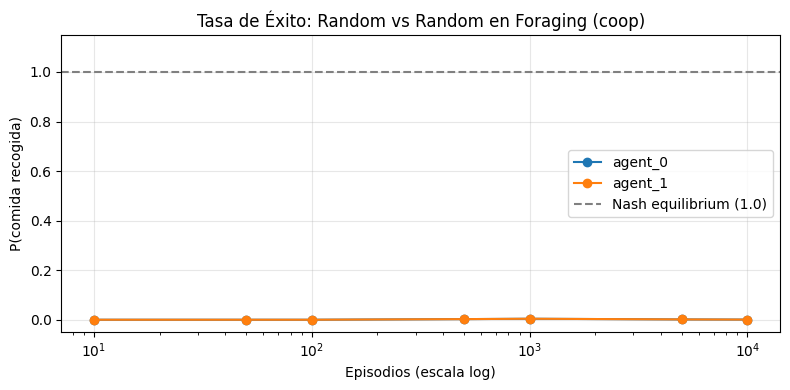

In [47]:
agents = {a: RandomAgent(game=game_coop, agent=a) for a in game_coop.agents}
history = track_success_rate(game_coop, agents, checkpoints)
plot_success_rate(history, checkpoints,
                  'Tasa de Éxito: Random vs Random en Foraging (coop)',
                  nash_eq=nash_eq_coop)

### IQL vs Random

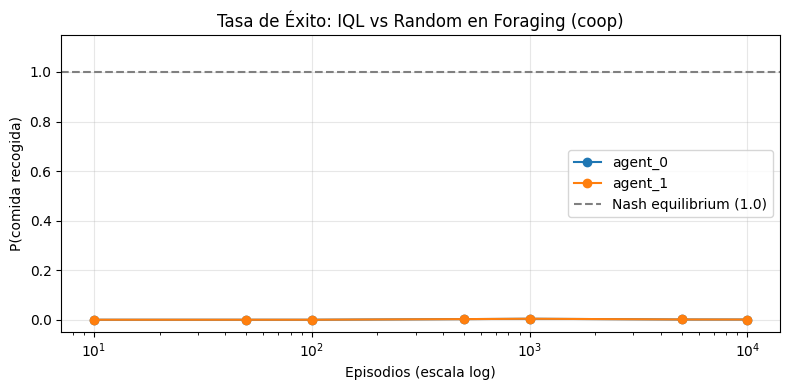

In [48]:
agents = {'agent_0': IndependentQLearning(game=game_coop, agent='agent_0'),
          'agent_1': RandomAgent(game=game_coop, agent='agent_1')}
history = track_success_rate(game_coop, agents, checkpoints)
plot_success_rate(history, checkpoints,
                  'Tasa de Éxito: IQL vs Random en Foraging (coop)',
                  nash_eq=nash_eq_coop)

### IQL vs IQL

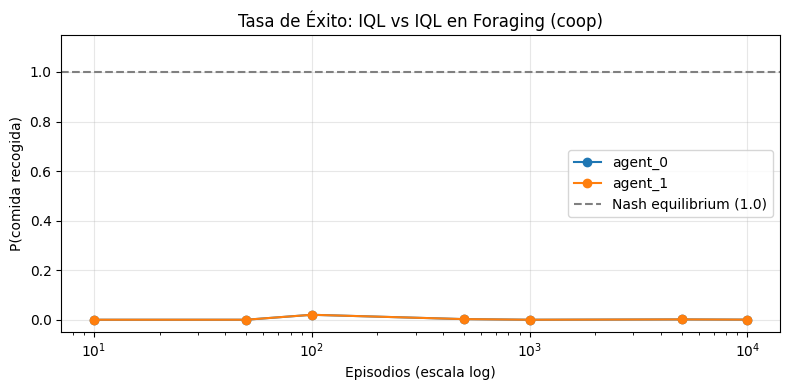

In [49]:
agents = {a: IndependentQLearning(game=game_coop, agent=a) for a in game_coop.agents}
history = track_success_rate(game_coop, agents, checkpoints)
plot_success_rate(history, checkpoints,
                  'Tasa de Éxito: IQL vs IQL en Foraging (coop)',
                  nash_eq=nash_eq_coop)

### JAL-AM vs JAL-AM

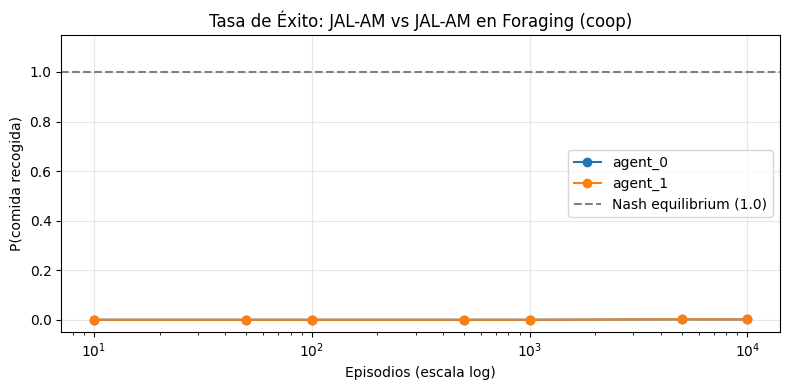

In [50]:
agents = {a: JointActionLearningAM(game=game_coop, agent=a) for a in game_coop.agents}
history = track_success_rate(game_coop, agents, checkpoints)
plot_success_rate(history, checkpoints,
                  'Tasa de Éxito: JAL-AM vs JAL-AM en Foraging (coop)',
                  nash_eq=nash_eq_coop)

### IQL vs JAL-AM

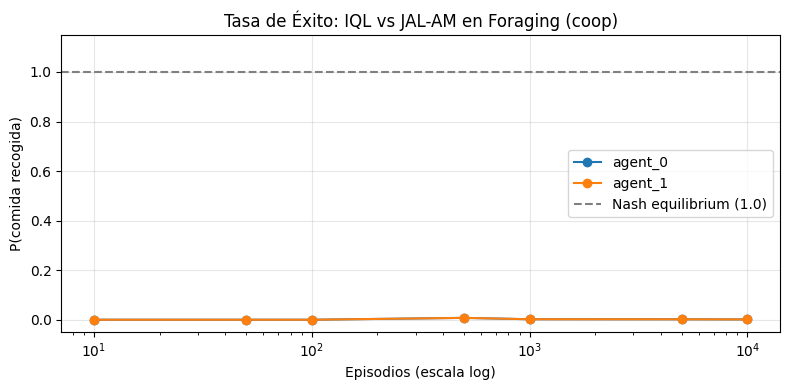

In [51]:
agents = {'agent_0': IndependentQLearning(game=game_coop, agent='agent_0'),
          'agent_1': JointActionLearningAM(game=game_coop, agent='agent_1')}
history = track_success_rate(game_coop, agents, checkpoints)
plot_success_rate(history, checkpoints,
                  'Tasa de Éxito: IQL vs JAL-AM en Foraging (coop)',
                  nash_eq=nash_eq_coop)